# Data Cleaning and Preprocessing

## Knowing the Data

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Term_Project_Dataset_20K.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          19400 non-null  float64
 1   gender                       19400 non-null  object 
 2   parent_income                19400 non-null  float64
 3   num_siblings                 19400 non-null  float64
 4   family_support               19400 non-null  float64
 5   commute_time_min             19400 non-null  float64
 6   part_time_job                19400 non-null  object 
 7   previous_gpa                 19400 non-null  float64
 8   num_failed_courses           19400 non-null  float64
 9   high_school_grade            19400 non-null  float64
 10  math_background_score        19400 non-null  float64
 11  language_background_score    19400 non-null  float64
 12  science_background_score     19400 non-null  float64
 13  prior_semester_c

In [4]:
df.head()

,age,gender,parent_income,num_siblings,family_support,commute_time_min,part_time_job,previous_gpa,num_failed_courses,high_school_grade,...,concentration_level,exam_anxiety_level,course_difficulty_rating,teacher_experience_years,class_size,num_prerequisites,course_type,final_score,final_grade,pass_fail
0,24.0,Female,22678.0,0.0,1.0,95.0,No,2.22,3.0,99.7,...,7.0,6.0,2.0,11.0,95.0,3.0,Elective,NaN,C,Pass
1,21.0,Male,17905.0,3.0,2.0,0.0,Yes,3.78,1.0,75.7,...,3.0,3.0,1.0,NaN,148.0,2.0,Elective,81.7,C,Pass
2,28.0,Male,NaN,0.0,0.0,67.0,No,NaN,4.0,93.4,...,1.0,8.0,1.0,32.0,55.0,3.0,Elective,77.3,B,Pass
3,25.0,Female,29391.0,4.0,4.0,83.0,Yes,1.84,4.0,69.7,...,6.0,10.0,5.0,30.0,42.0,1.0,Mandatory,78.5,B,Pass
4,22.0,Male,15522.0,0.0,4.0,58.0,Yes,3.38,0.0,62.2,...,10.0,5.0,3.0,31.0,123.0,1.0,Mandatory,60.3,D,Pass


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,19400.0,23.478918,3.452709,18.0,20.00,23.0,26.00,29.0
parent_income,19400.0,18290.515928,30896.118002,2000.0,9087.00,16102.0,23108.50,596760.0
num_siblings,19400.0,2.510361,1.715978,0.0,1.00,3.0,4.00,5.0
family_support,19400.0,2.502680,1.707515,0.0,1.00,3.0,4.00,5.0
commute_time_min,19400.0,59.318144,34.796772,0.0,29.00,59.0,90.00,119.0
previous_gpa,19400.0,2.491322,0.869089,1.0,1.73,2.5,3.24,4.0
num_failed_courses,19400.0,1.996443,1.413680,0.0,1.00,2.0,3.00,4.0
high_school_grade,19400.0,74.902892,14.425122,50.0,62.40,74.8,87.40,100.0
math_background_score,19400.0,49.352577,28.890298,0.0,24.00,49.0,74.00,99.0
language_background_score,19400.0,49.412268,28.842990,0.0,24.00,49.0,75.00,99.0


In [6]:
df.isnull()

,age,gender,parent_income,num_siblings,family_support,commute_time_min,part_time_job,previous_gpa,num_failed_courses,high_school_grade,...,concentration_level,exam_anxiety_level,course_difficulty_rating,teacher_experience_years,class_size,num_prerequisites,course_type,final_score,final_grade,pass_fail
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


* Dataset size of 20,000
* 600 missing entries in each column (not for the same sample)
* Maximum lecture attendance rate=150?
* Negative Stress Levels?
* Negative Sleep Hours?
* 36 Numerical Features
* 5 Categorical Features

## Fixing Impossible Values

We set impossible values to NaN

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_dist(df_to_plot, name):
  # Choose the feature you want to plot
  feature_to_plot = name # Replace 'age' with the actual column name from your DataFrame

  plt.figure(figsize=(10, 6))

  # Check the data type of the feature to decide the appropriate plot
  if df_to_plot[feature_to_plot].dtype in ['int64', 'float64']:
      # For numerical features, use a histogram or displot
      sns.histplot(df_to_plot[feature_to_plot].dropna(), kde=True)
      plt.title(f'Distribution of {feature_to_plot}')
      plt.xlabel(feature_to_plot)
      plt.ylabel('Frequency')
  elif df_to_plot[feature_to_plot].dtype == 'object':
      # For categorical features, use a countplot
      sns.countplot(y=df_to_plot[feature_to_plot].dropna(), order=df_to_plot[feature_to_plot].value_counts().index)
      plt.title(f'Distribution of {feature_to_plot}')
      plt.xlabel('Count')
      plt.ylabel(feature_to_plot)
  else:
      print(f"Unsupported data type for {feature_to_plot}: {df_to_plot[feature_to_plot].dtype}")

  plt.tight_layout()
  plt.show()

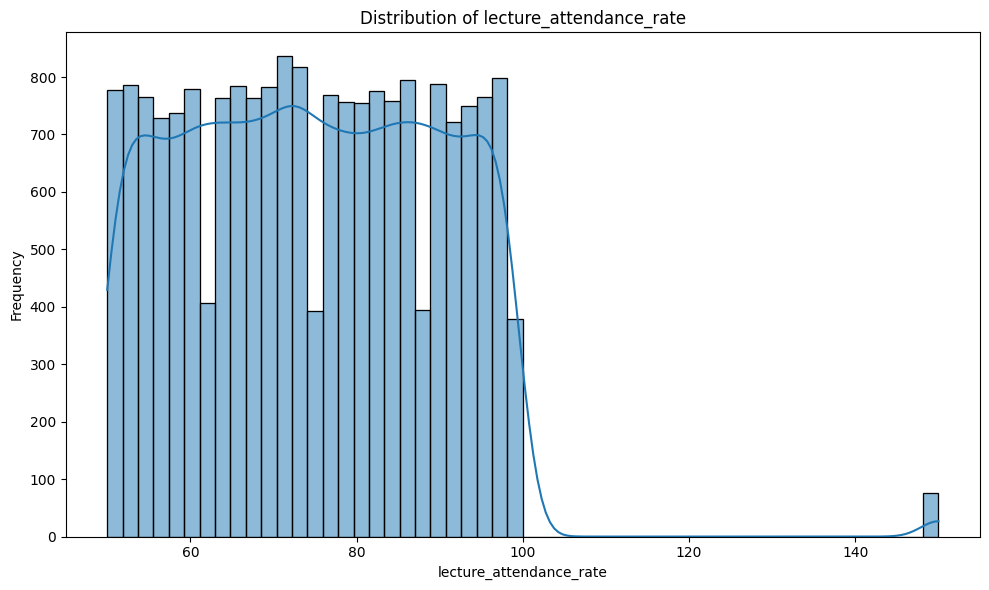

In [8]:
plot_dist(df,name='lecture_attendance_rate')

In [9]:
import numpy as np
df.loc[df['lecture_attendance_rate'] > 100, 'lecture_attendance_rate'] = np.nan

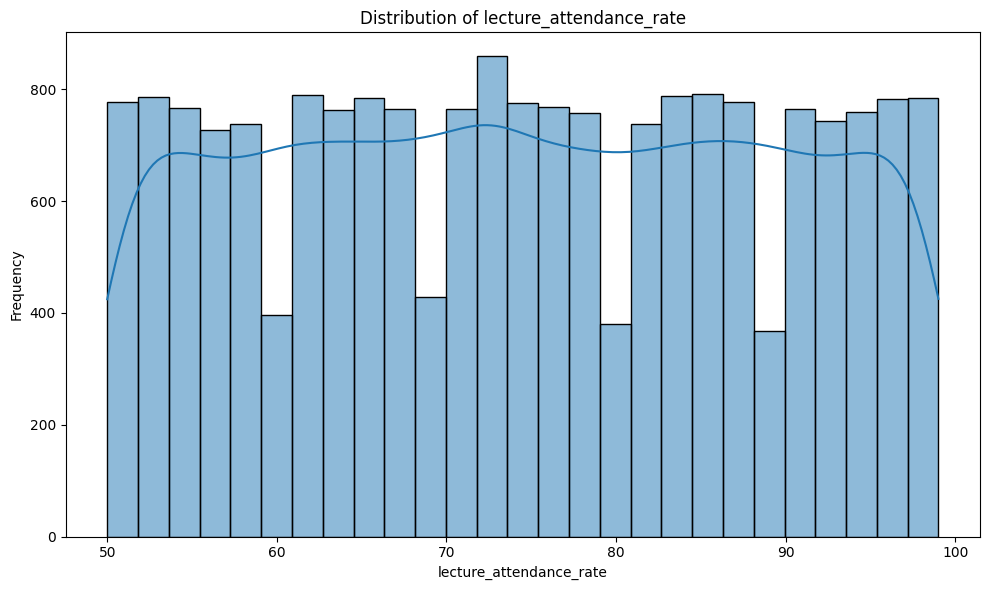

In [10]:
plot_dist(df,name='lecture_attendance_rate')

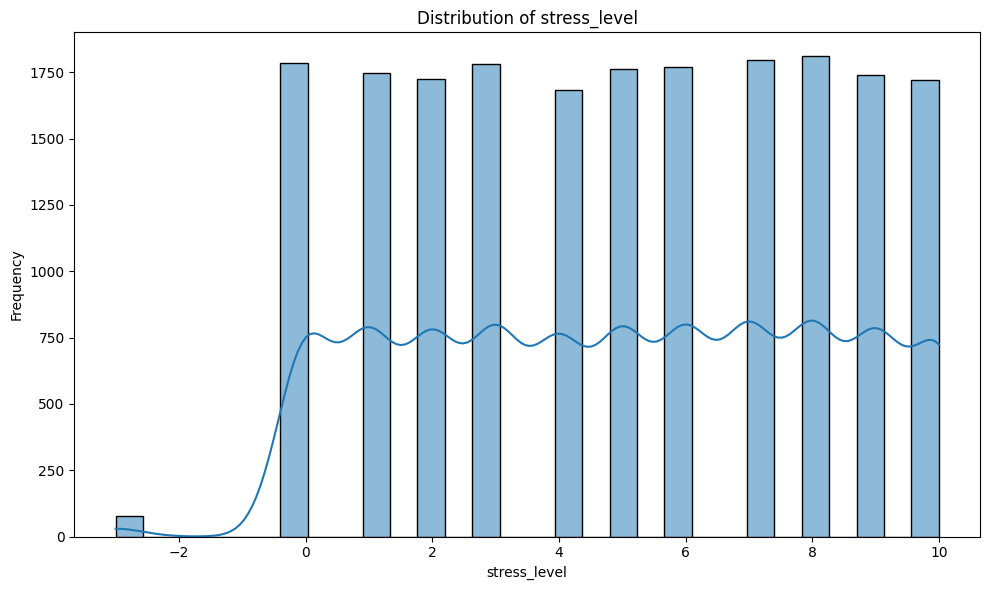

In [11]:
plot_dist(df,'stress_level')

In [12]:
import numpy as np
df.loc[df['stress_level'] < 0, 'stress_level'] = np.nan

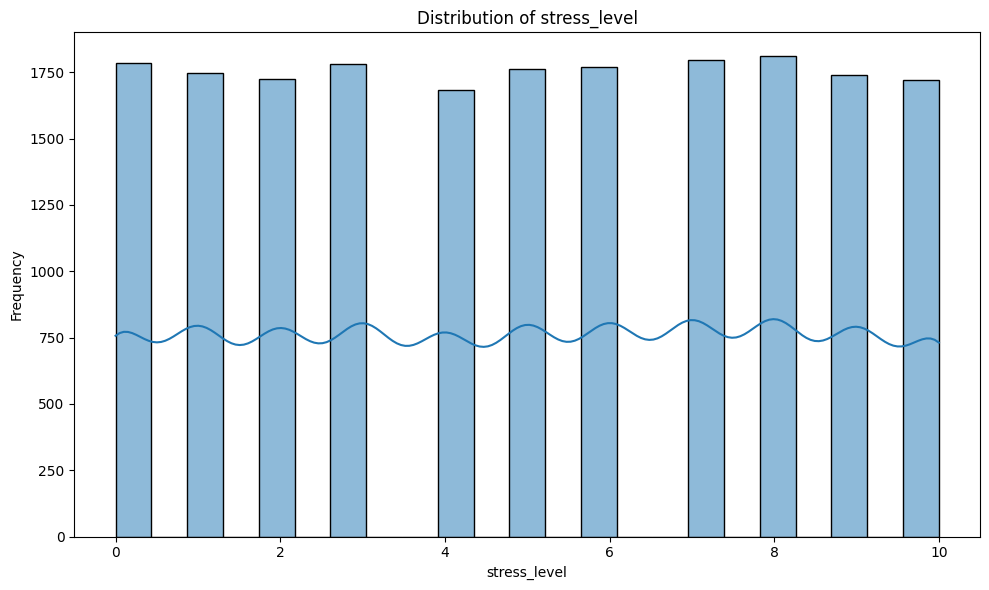

In [13]:
plot_dist(df,'stress_level')

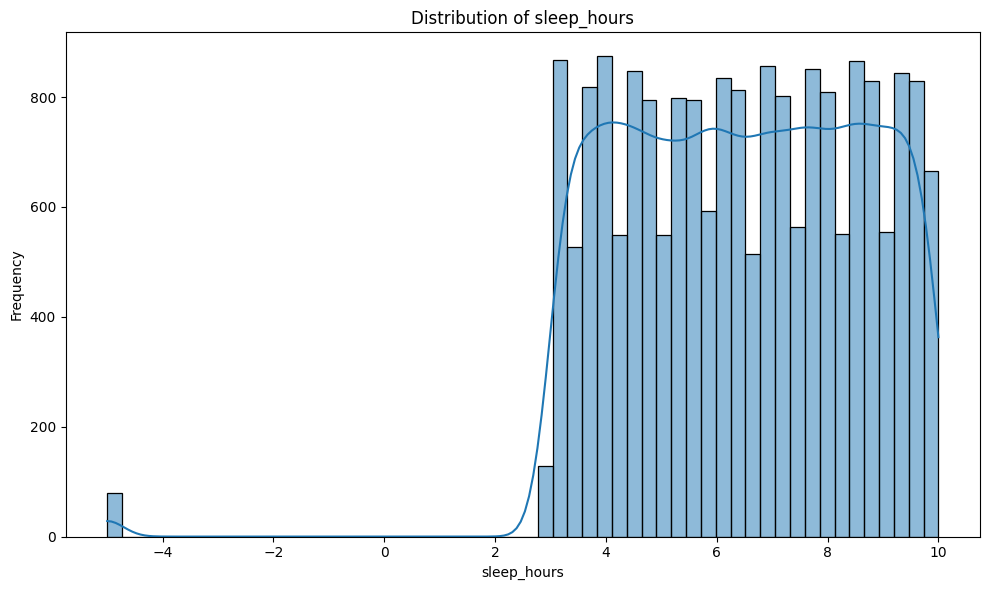

In [14]:
plot_dist(df,'sleep_hours')

In [15]:
import numpy as np
df.loc[df['sleep_hours'] < 0, 'sleep_hours'] = np.nan

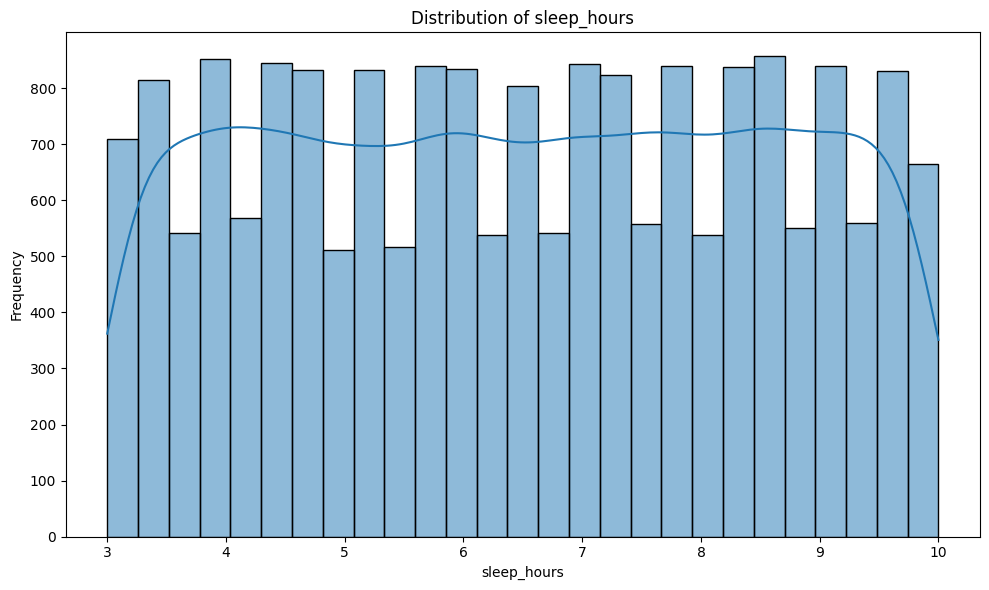

In [16]:
plot_dist(df,'sleep_hours')

In [17]:
df.isnull().sum()

age                            600
gender                         600
parent_income                  600
num_siblings                   600
family_support                 600
commute_time_min               600
part_time_job                  600
previous_gpa                   600
num_failed_courses             600
high_school_grade              600
math_background_score          600
language_background_score      600
science_background_score       600
prior_semester_credits         600
study_hours_last_semester      600
past_attendance_rate           600
academic_warnings_count        600
lecture_attendance_rate        676
assignment_submission_rate     600
quiz_avg_score                 600
midterm_score                  600
lab_participation_rate         600
online_portal_usage_minutes    600
group_project_activity         600
library_visits_per_month       600
discussion_forum_posts         600
lateness_count                 600
stress_level                   676
sleep_hours         

## Imputing Numerical Features

In [18]:
import numpy as np
from sklearn.impute import KNNImputer
numerical_features = df.select_dtypes(include=np.number).columns.drop('final_score')
imputer = KNNImputer(n_neighbors=5)
df[numerical_features] = imputer.fit_transform(df[numerical_features])

In [19]:
df.isnull().sum()

age                              0
gender                         600
parent_income                    0
num_siblings                     0
family_support                   0
commute_time_min                 0
part_time_job                  600
previous_gpa                     0
num_failed_courses               0
high_school_grade                0
math_background_score            0
language_background_score        0
science_background_score         0
prior_semester_credits           0
study_hours_last_semester        0
past_attendance_rate             0
academic_warnings_count          0
lecture_attendance_rate          0
assignment_submission_rate       0
quiz_avg_score                   0
midterm_score                    0
lab_participation_rate           0
online_portal_usage_minutes      0
group_project_activity           0
library_visits_per_month         0
discussion_forum_posts           0
lateness_count                   0
stress_level                     0
sleep_hours         

## Imputing Categorical Features

* Since non of the feature values are dominant in any of the categorical features with missing values using the mode could be misleading for the model
* Adding a 3rd "unknown" value to the categorical feature could provide additional information to the model since the missing 600 samples could have a common pattern

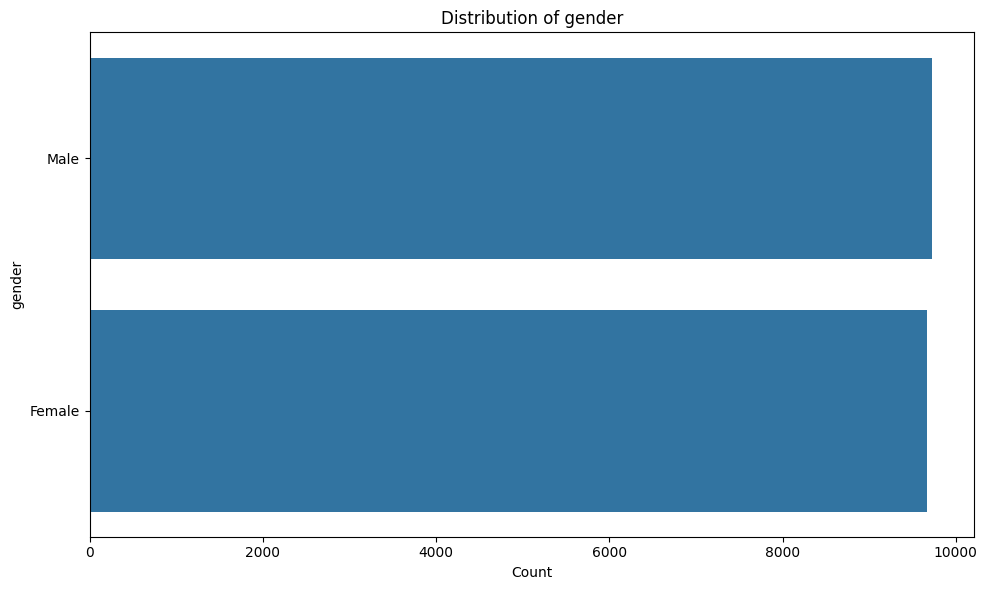

In [20]:
plot_dist(df,'gender')

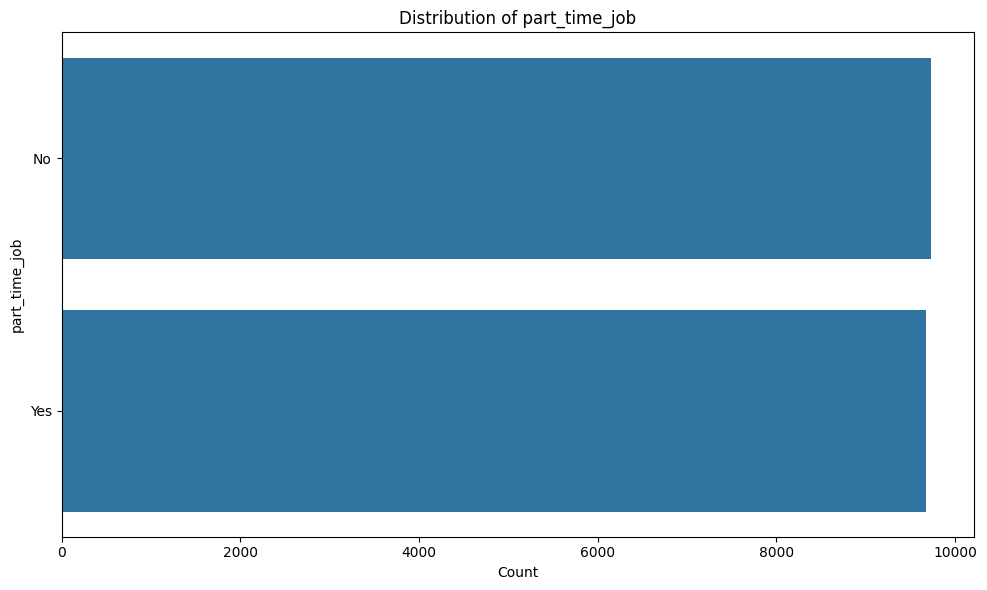

In [21]:
plot_dist(df,'part_time_job')

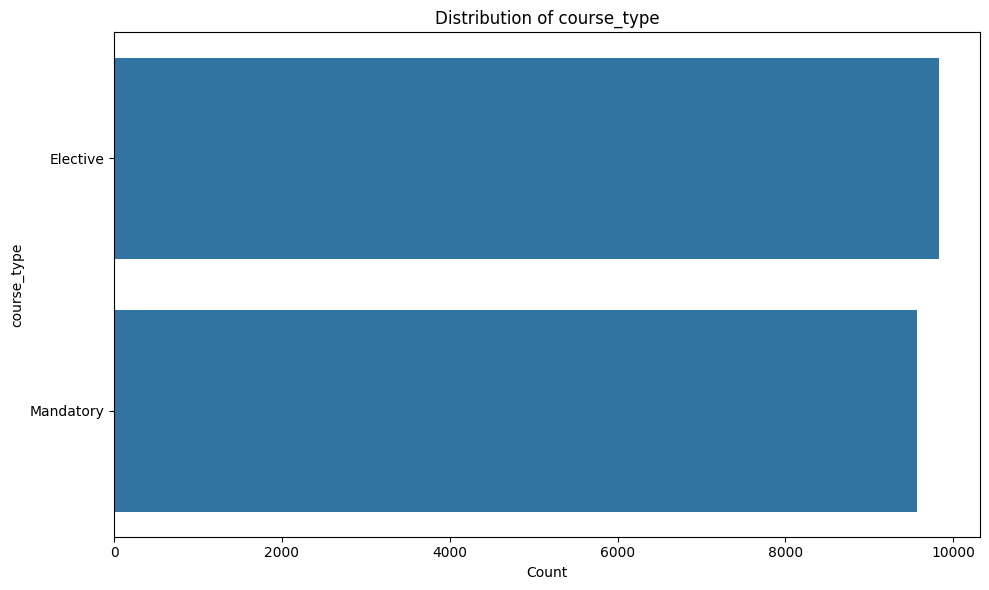

In [22]:
plot_dist(df,'course_type')

In [23]:
cat_cols = ['gender', 'part_time_job', 'course_type']
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [24]:
df.isnull().sum()

age                              0
gender                           0
parent_income                    0
num_siblings                     0
family_support                   0
commute_time_min                 0
part_time_job                    0
previous_gpa                     0
num_failed_courses               0
high_school_grade                0
math_background_score            0
language_background_score        0
science_background_score         0
prior_semester_credits           0
study_hours_last_semester        0
past_attendance_rate             0
academic_warnings_count          0
lecture_attendance_rate          0
assignment_submission_rate       0
quiz_avg_score                   0
midterm_score                    0
lab_participation_rate           0
online_portal_usage_minutes      0
group_project_activity           0
library_visits_per_month         0
discussion_forum_posts           0
lateness_count                   0
stress_level                     0
sleep_hours         

## Encoding Categorical Features

In [25]:
df = pd.get_dummies(df, columns=cat_cols,drop_first=True)
drop_first=True
print(df.columns)

Index(['age', 'parent_income', 'num_siblings', 'family_support',
       'commute_time_min', 'previous_gpa', 'num_failed_courses',
       'high_school_grade', 'math_background_score',
       'language_background_score', 'science_background_score',
       'prior_semester_credits', 'study_hours_last_semester',
       'past_attendance_rate', 'academic_warnings_count',
       'lecture_attendance_rate', 'assignment_submission_rate',
       'quiz_avg_score', 'midterm_score', 'lab_participation_rate',
       'online_portal_usage_minutes', 'group_project_activity',
       'library_visits_per_month', 'discussion_forum_posts', 'lateness_count',
       'stress_level', 'sleep_hours', 'motivation_level',
       'study_time_per_week', 'concentration_level', 'exam_anxiety_level',
       'course_difficulty_rating', 'teacher_experience_years', 'class_size',
       'num_prerequisites', 'final_score', 'final_grade', 'pass_fail',
       'gender_Male', 'gender_Unknown', 'part_time_job_Unknown',
       'part

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          20000 non-null  float64
 1   parent_income                20000 non-null  float64
 2   num_siblings                 20000 non-null  float64
 3   family_support               20000 non-null  float64
 4   commute_time_min             20000 non-null  float64
 5   previous_gpa                 20000 non-null  float64
 6   num_failed_courses           20000 non-null  float64
 7   high_school_grade            20000 non-null  float64
 8   math_background_score        20000 non-null  float64
 9   language_background_score    20000 non-null  float64
 10  science_background_score     20000 non-null  float64
 11  prior_semester_credits       20000 non-null  float64
 12  study_hours_last_semester    20000 non-null  float64
 13  past_attendance_

In [27]:
targets = ['final_score', 'final_grade', 'pass_fail']
features = [col for col in df.columns if col not in targets]
df = df[features + targets]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          20000 non-null  float64
 1   parent_income                20000 non-null  float64
 2   num_siblings                 20000 non-null  float64
 3   family_support               20000 non-null  float64
 4   commute_time_min             20000 non-null  float64
 5   previous_gpa                 20000 non-null  float64
 6   num_failed_courses           20000 non-null  float64
 7   high_school_grade            20000 non-null  float64
 8   math_background_score        20000 non-null  float64
 9   language_background_score    20000 non-null  float64
 10  science_background_score     20000 non-null  float64
 11  prior_semester_credits       20000 non-null  float64
 12  study_hours_last_semester    20000 non-null  float64
 13  past_attendance_

## Handling Outliers

In [29]:
import pandas as pd
numerical_cols = df.select_dtypes(include=['number']).columns

outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

outlier_report = pd.Series(outlier_counts).sort_values(ascending=False)
print("Outlier Count Per Feature:")
print(outlier_report)

Outlier Count Per Feature:
parent_income                  149
online_portal_usage_minutes    149
study_hours_last_semester      146
final_score                     45
family_support                   0
num_siblings                     0
age                              0
commute_time_min                 0
math_background_score            0
language_background_score        0
num_failed_courses               0
previous_gpa                     0
prior_semester_credits           0
past_attendance_rate             0
academic_warnings_count          0
lecture_attendance_rate          0
assignment_submission_rate       0
quiz_avg_score                   0
science_background_score         0
high_school_grade                0
lab_participation_rate           0
midterm_score                    0
library_visits_per_month         0
group_project_activity           0
lateness_count                   0
stress_level                     0
sleep_hours                      0
discussion_forum_posts      

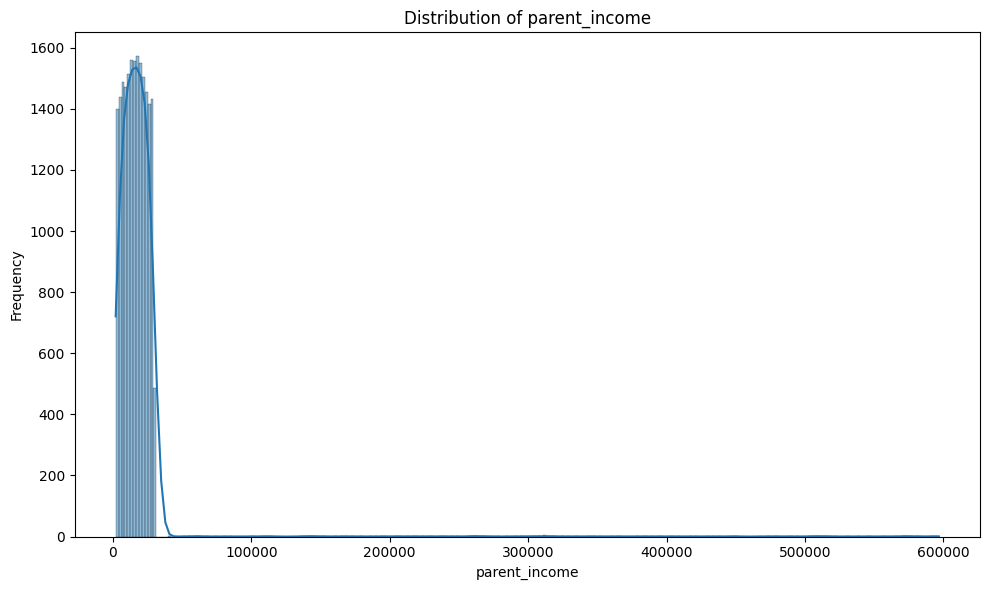

In [30]:
plot_dist(df,'parent_income')

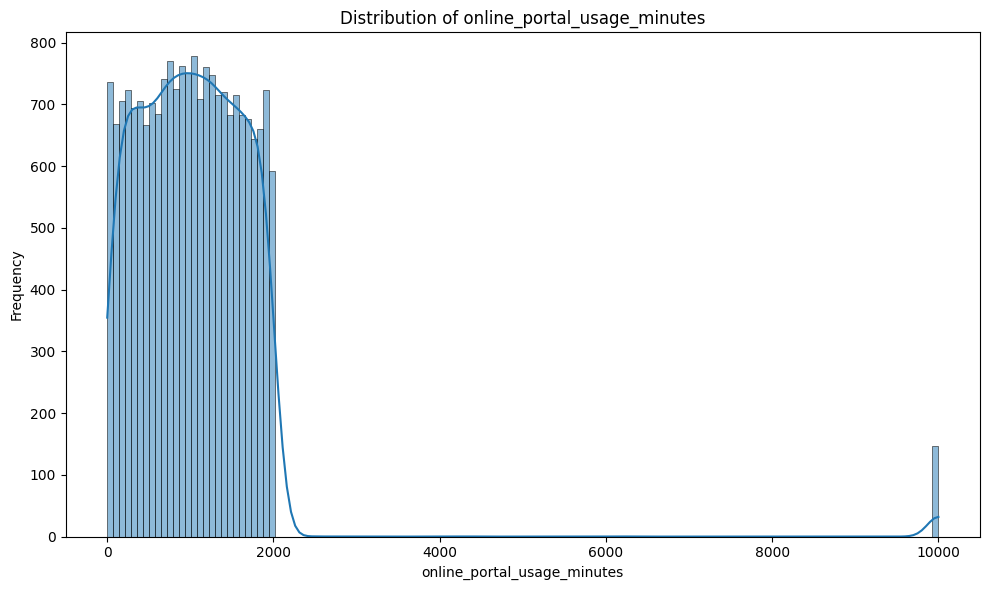

In [31]:
plot_dist(df,'online_portal_usage_minutes')

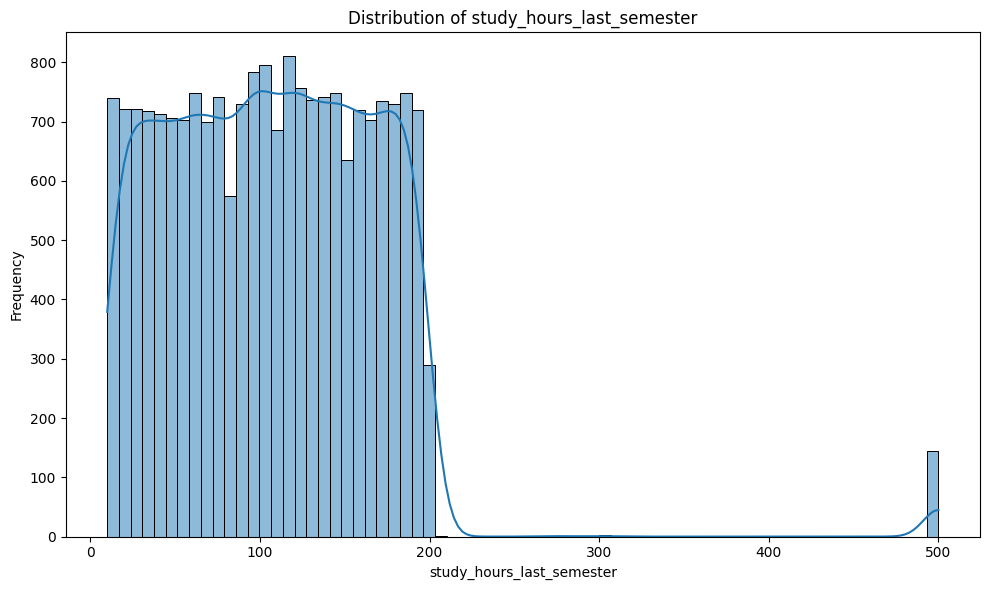

In [32]:
plot_dist(df,'study_hours_last_semester')

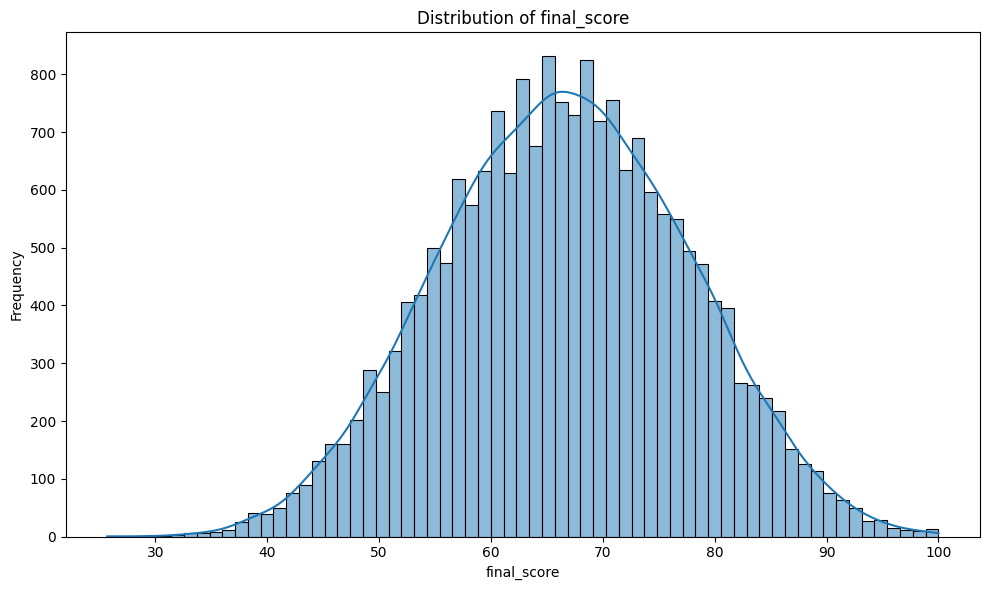

In [33]:
plot_dist(df,'final_score')

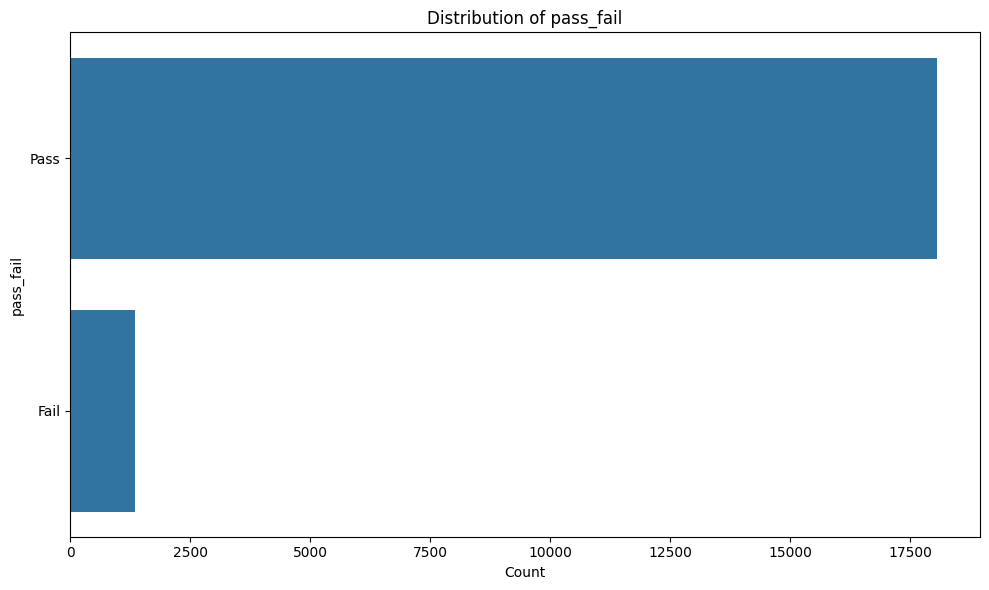

In [34]:
plot_dist(df,'pass_fail')

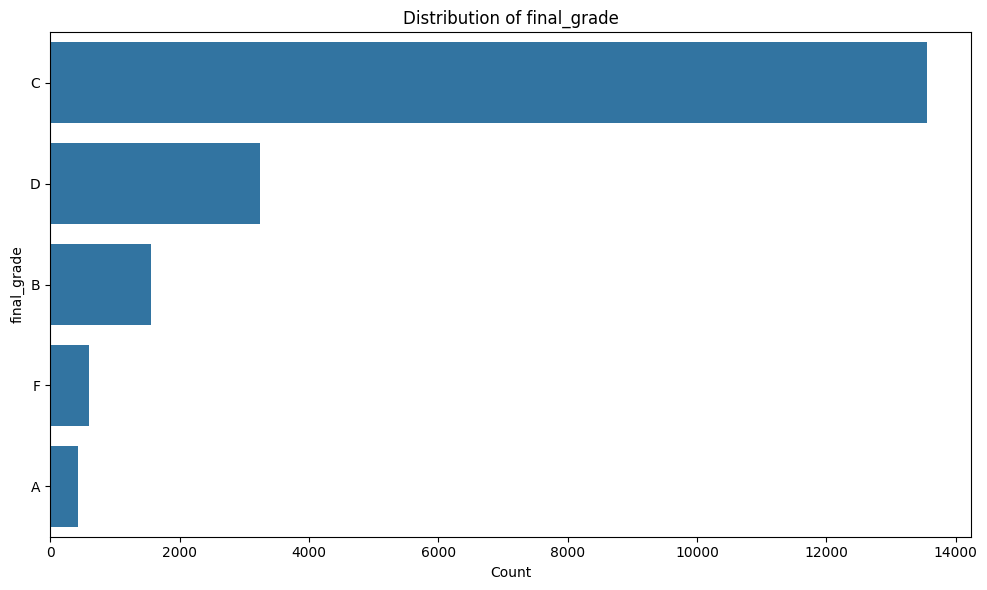

In [35]:
plot_dist(df,'final_grade')

# Final Score

In [143]:
df_final_score=df.drop(columns=["pass_fail","final_grade"])

In [145]:
train_df = df_final_score[df_final_score['final_score'].notna()]
predict_df = df_final_score[df_final_score['final_score'].isna()]

In [149]:
correlation_matrix = train_df.corr(numeric_only=True)

# Filter for correlations greater than 0.5 in magnitude, excluding self-correlations
high_correlations = {}
for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if col != row and abs(correlation_matrix.loc[row, col]) > 0.5:
            # Store each pair only once (e.g., A-B not B-A)
            if f'{row}-{col}' not in high_correlations and f'{col}-{row}' not in high_correlations:
                high_correlations[f'{row}-{col}'] = correlation_matrix.loc[row, col]

# Sort the correlations by magnitude
sorted_high_correlations = sorted(high_correlations.items(), key=lambda item: abs(item[1]), reverse=True)

for pair, correlation in sorted_high_correlations:
    print(f"Correlation between {pair}: {correlation:.4f}")

Correlation between online_portal_usage_minutes-parent_income: 0.6821
Correlation between final_score-midterm_score: 0.6428


In [151]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = train_df.drop('final_score', axis=1)
y = train_df['final_score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (13580, 41)
X_test shape: (5820, 41)
y_train shape: (13580,)
y_test shape: (5820,)


In [152]:
from sklearn.preprocessing import StandardScaler

# Identify numerical and boolean columns
numerical_cols = X_train.select_dtypes(include=['float64']).columns
boolean_cols = X_train.select_dtypes(include=['bool']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the numerical training data and transform both numerical training and test data
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_numerical_scaled = scaler.transform(X_test[numerical_cols])

# Convert the scaled arrays back to DataFrames, retaining column names
X_train_numerical_scaled = pd.DataFrame(X_train_numerical_scaled, columns=numerical_cols)
X_test_numerical_scaled = pd.DataFrame(X_test_numerical_scaled, columns=numerical_cols)

# Combine scaled numerical features with original boolean features
X_train_scaled = pd.concat([X_train_numerical_scaled, X_train[boolean_cols].reset_index(drop=True)], axis=1)
X_test_scaled = pd.concat([X_test_numerical_scaled, X_test[boolean_cols].reset_index(drop=True)], axis=1)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
display(X_train_scaled.head())

X_train_scaled shape: (13580, 41)
X_test_scaled shape: (5820, 41)


,age,parent_income,num_siblings,family_support,commute_time_min,previous_gpa,num_failed_courses,high_school_grade,math_background_score,language_background_score,...,course_difficulty_rating,teacher_experience_years,class_size,num_prerequisites,gender_Male,gender_Unknown,part_time_job_Unknown,part_time_job_Yes,course_type_Mandatory,course_type_Unknown
0,-1.595307,0.222887,-0.886818,0.294116,0.895367,1.288856,1.445454,-0.960721,-0.046579,-1.492721,...,-1.431336,-0.095515,1.046333,0.726297,False,False,False,False,False,True
1,-1.302671,0.333958,-1.477873,-0.297970,0.603452,-1.108265,-0.714092,1.685893,0.232564,0.090467,...,-0.712992,-0.633154,0.150716,0.726297,False,False,False,True,True,False
2,0.453141,-0.072211,-0.886818,-0.297970,-1.235612,-0.049342,1.445454,1.405085,0.232564,-1.598267,...,0.723698,-0.901973,1.007393,1.444471,True,False,False,True,False,False
3,-0.424765,-0.024246,0.295293,-1.482141,-1.031271,-1.317722,-1.433940,-0.679913,0.825742,0.674487,...,-0.712992,-1.260399,-0.258153,1.444471,True,False,False,False,True,False
4,-0.424765,0.123254,-0.886818,-0.890056,-1.381569,-1.096628,0.005757,-1.059004,1.314241,-1.105719,...,0.005353,-1.260399,-0.822781,0.726297,False,False,False,False,False,False


In [153]:
import statsmodels.api as sm

# Convert boolean columns to integer (0 or 1) for statsmodels compatibility
X_train_scaled_numeric = X_train_scaled.copy()
for col in X_train_scaled_numeric.select_dtypes(include=['bool']).columns:
    X_train_scaled_numeric[col] = X_train_scaled_numeric[col].astype(int)

# Add a constant (intercept) to the independent variables for statsmodels
X_train_sm = sm.add_constant(X_train_scaled_numeric)

# Reset index of y_train to align with X_train_sm
y_train_aligned = y_train.reset_index(drop=True)

# Create and fit the OLS model
ols_model = sm.OLS(y_train_aligned, X_train_sm)
ols_results = ols_model.fit()

# Print the model summary
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     1074.
Date:                Sun, 28 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:19:25   Log-Likelihood:                -42048.
No. Observations:               13580   AIC:                         8.418e+04
Df Residuals:                   13538   BIC:                         8.450e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

Main Academic Predictors


* Midterm Score (coef: 7.20): This is the strongest predictor. For every unit increase in the midterm score, the final score is expected to rise by 7.15 points, holding all other factors constant.

*  Quiz Average Score (coef: 4.28): Consistent performance on quizzes is the second strongest predictor.

* Assignment Submission Rate (coef: 3.53): Simply turning in work on time has a massive positive impact.

* Lecture Attendance Rate (coef: 3.53): Showing up to class is strongly linked to success

* Stress Level (coef: -0.29): Higher stress levels are clearly detrimental to the final score, even when accounting for academic performance.

* Course Difficulty Rating (coef: 0.10): Interestingly, students who rate the course as more difficult tend to have slightly higher scores. This could suggest that high-achieving students are more aware of the complexities of the material.

* Sleep Hours (coef: -0.09): Interestingly, the coefficient is negative. This suggests that in this specific dataset, students sleeping for longer durations might actually see a slight decrease in scores, potentially indicating a "trade-off" where excessive sleep cuts into critical study time, or that high-performing students are sacrificing some sleep to maintain their grades.

* Part-time Job (coef: -0.19): Having a job has a small but significant negative impact, likely due to reduced cognitive bandwidth and time for deep study.

The condition number shows there are very little traces of multicollinearity.



## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Fit the model to the scaled training data
linear_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = linear_model.predict(X_test_scaled)

y_train_pred=linear_model.predict(X_train_scaled)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2=r2_score(y_test, y_pred)

print(f"Train Mean Squared Error (MSE) for the sklearn Linear Model: {train_mse:.4f}")
print(f"Train Root Mean Squared Error (RMSE) for the sklearn Linear Model: {train_rmse:.4f}")
print(f"Train R^2 for the sklearn Linear Model: {train_r2:.4f}")
print(f"Mean Squared Error (MSE) for the sklearn Linear Model: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) for the sklearn Linear Model: {rmse:.4f}")
print(f"Test R^2 for the sklearn Linear Model: {test_r2:.4f}")


Linear Regression model fitted successfully!


## Lasso Regression

In [125]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# Initialize LassoCV model
# n_alphas determines how many alphas to check. cv specifies the number of folds for cross-validation.
lasso_cv_model = LassoCV(alphas=None, cv=5, random_state=42, max_iter=10000)

# Fit the model to the scaled training data
lasso_cv_model.fit(X_train_scaled, y_train)

print(f"Best alpha found by LassoCV: {lasso_cv_model.alpha_:.4f}")

# Make predictions on the training data
y_train_pred_lasso = lasso_cv_model.predict(X_train_scaled)

# Calculate MSE for the training set
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

# Make predictions on the test data
y_test_pred_lasso = lasso_cv_model.predict(X_test_scaled)

# Calculate MSE for the test set
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"\nLassoCV Mean Squared Error (Training Set): {mse_train_lasso:.4f}")
print(f"LassoCV R-squared (Training Set): {r2_train_lasso:.4f}")
print(f"LassoCV Mean Squared Error (Test Set): {mse_test_lasso:.4f}")
print(f"LassoCV R-squared (Test Set): {r2_test_lasso:.4f}")

Best alpha found by LassoCV: 0.0577

LassoCV Mean Squared Error (Training Set): 28.7290
LassoCV R-squared (Training Set): 0.7641
LassoCV Mean Squared Error (Test Set): 28.1695
LassoCV R-squared (Test Set): 0.7706


## Linear SVR

In [89]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize SVR model
# SVR can be computationally intensive, so it might take some time to run.
# For a first pass, we'll use default parameters.
svr_model = SVR()

# Fit the model to the scaled training data
print("Fitting SVR model... This may take a while.")
svr_model.fit(X_train_scaled, y_train)
print("SVR model fitted successfully!")

# Make predictions on the training data
y_train_pred_svr = svr_model.predict(X_train_scaled)

# Calculate MSE and R-squared for the training set
mse_train_svr = mean_squared_error(y_train, y_train_pred_svr)
r2_train_svr = r2_score(y_train, y_train_pred_svr)

# Make predictions on the test data
y_test_pred_svr = svr_model.predict(X_test_scaled)

# Calculate MSE and R-squared for the test set
mse_test_svr = mean_squared_error(y_test, y_test_pred_svr)
r2_test_svr = r2_score(y_test, y_test_pred_svr)

print(f"\nSVR Mean Squared Error (Training Set): {mse_train_svr:.4f}")
print(f"SVR R-squared (Training Set): {r2_train_svr:.4f}")
print(f"SVR Mean Squared Error (Test Set): {mse_test_svr:.4f}")
print(f"SVR R-squared (Test Set): {r2_test_svr:.4f}")

Fitting SVR model... This may take a while.
SVR model fitted successfully!

SVR Mean Squared Error (Training Set): 28.4577
SVR R-squared (Training Set): 0.7663
SVR Mean Squared Error (Test Set): 31.4883
SVR R-squared (Test Set): 0.7436


## Non-Linear SVR

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
import numpy as np

# 1. Define a distribution rather than a fixed list
# This allows the search to try a wider variety of values
param_distributions = {
    # Move into higher penalty zones
    'C': [0.1,1,10,50, 100],

    # Test finer influence ranges
    'gamma': [0.01, 0.05, 0.1, 'scale'],

    # Force the model to be more precise
    'epsilon': [0.01, 0.05, 0.1,0.2],

    'kernel': ['rbf']
}

# Increase n_iter to 20 to give it more chances to find the "sweet spot"
random_search = RandomizedSearchCV(
    SVR(),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,         # 3-fold is fine for 13k rows and faster
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=42
)


print("Starting RandomizedSearchCV... this will be much faster.")
random_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best MSE (CV): {-random_search.best_score_:.4f}")


from sklearn.metrics import mean_squared_error

# 1. Get the best model from the search
best_svr = random_search.best_estimator_

# 2. Generate predictions for both sets
y_pred_train = best_svr.predict(X_train_scaled)
y_pred_test = best_svr.predict(X_test_scaled)

# 3. Calculate Errors
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
cv_mse = -random_search.best_score_  # Convert negative MSE back to positive

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)


print("\n" + "="*40)
print(f"SVR MODEL PERFORMANCE SUMMARY")
print("="*40)
print(f"Best Parameters: {random_search.best_params_}")
print("-" * 40)
print(f"MSE (Training Set): {train_mse:.4f}")
print(f"MSE (Cross-Val):   {cv_mse:.4f}")
print(f"MSE (Test Set):     {test_mse:.4f}")
print("-" * 40)
print(f"R^2 (Training Set): {train_r2:.4f}")
print(f"R^2 (Test Set):     {test_r2:.4f}")
print("-" * 40)

Starting RandomizedSearchCV... this will be much faster.
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.2, 'C': 1}
Best MSE (CV): 30.3558

SVR MODEL PERFORMANCE SUMMARY
Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.2, 'C': 1}
----------------------------------------
MSE (Training Set): 28.8882
MSE (Cross-Val):   30.3558
MSE (Test Set):     29.5221
----------------------------------------
Diagnostic: Potential Underfitting (Model is not beating the OLS baseline).


## Reducing Dimensionality

In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# 1. Define the features (X) and target (y)
X = train_df.drop(columns=['final_score'])
y = train_df['final_score']

# 2. Initialize the Linear Regression model
lin_reg = LinearRegression()

# 3. Use RFE to select the top 10 features
# This creates the 'selector' object your code was looking for
selector = RFE(estimator=lin_reg, n_features_to_select=10)
selector.fit(X, y)

# --- YOUR ORIGINAL CODE STARTS HERE ---
feature_columns = X.columns

# This will now work because 'selector' is defined and fitted
selected_features = [f for f, s in zip(feature_columns, selector.support_) if s]

print("The Top 10 Signal-Rich Features are:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat}")

The Top 10 Signal-Rich Features are:
1. lecture_attendance_rate
2. assignment_submission_rate
3. quiz_avg_score
4. midterm_score
5. stress_level
6. course_difficulty_rating
7. gender_Unknown
8. part_time_job_Yes
9. course_type_Mandatory
10. course_type_Unknown


In [130]:
# Transform the data to only include the top 10 features
X_train_lean = selector.transform(X_train_scaled)
X_test_lean = selector.transform(X_test_scaled)

# Train a new OLS on just these 10
lean_ols = LinearRegression()
lean_ols.fit(X_train_lean, y_train)

# Calculate new errors
train_mse_lean = mean_squared_error(y_train, lean_ols.predict(X_train_lean))
test_mse_lean = mean_squared_error(y_test, lean_ols.predict(X_test_lean))

print(f"\nLean OLS Train MSE: {train_mse_lean:.4f}")
print(f"Lean OLS Test MSE:  {test_mse_lean:.4f}")
print(f"Original OLS Test MSE: 28.2216")


Lean OLS Train MSE: 28.7054
Lean OLS Test MSE:  28.1757
Original OLS Test MSE: 28.2216


In [131]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

# 1. Transform the data based on your RFE selector
X_train_lean = selector.transform(X_train_scaled)
X_test_lean = selector.transform(X_test_scaled)

# 2. Set up a balanced grid for the smaller feature space
param_dist_lean = {
    'C': [0,1,1,5, 10, 20, 30],         # Searching between the "lazy" C=1 and "overfit" C=50
    'gamma': ['scale', 0.01, 0.05],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

svr_lean = SVR()

# 3. Randomized Search
random_search_lean = RandomizedSearchCV(
    svr_lean,
    param_distributions=param_dist_lean,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_squared_error',
    random_state=42
)

print("Training SVR on Lean Features...")
random_search_lean.fit(X_train_lean, y_train)

# 4. Evaluate
best_svr_lean = random_search_lean.best_estimator_
train_mse_lean = mean_squared_error(y_train, best_svr_lean.predict(X_train_lean))
test_mse_lean = mean_squared_error(y_test, best_svr_lean.predict(X_test_lean))

print("\n" + "="*40)
print(f"LEAN SVR PERFORMANCE (10 Features)")
print("="*40)
print(f"Best Params: {random_search_lean.best_params_}")
print(f"MSE (Train): {train_mse_lean:.4f}")
print(f"MSE (Test):  {test_mse_lean:.4f}")
print(f"OLS Baseline: 28.2216")
print("="*40)

Training SVR on Lean Features...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


C:\Users\youss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\youss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\youss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packag


LEAN SVR PERFORMANCE (10 Features)
Best Params: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.5, 'C': 5}
MSE (Train): 28.7209
MSE (Test):  28.2920
OLS Baseline: 28.2216


## Interaction and Polynomial Terms

In [133]:
# Ensure X_selected is the DataFrame version of your top 10 features
X_selected = train_df[selected_features] 

# 1. Initialize and Transform
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_array = poly.fit_transform(X_selected)

# 2. Get the feature names
poly_feature_names = poly.get_feature_names_out(selected_features)

# 3. Create the DataFrame using X_selected.index
# If X_selected is a DataFrame, this will now work perfectly.
X_poly_df = pd.DataFrame(
    X_poly_array, 
    columns=poly_feature_names, 
    index=X_selected.index
)

print(f"Success! Shape is now: {X_poly_df.shape}")

Success! Shape is now: (19400, 65)


In [134]:
# Statsmodels OLS does not include an intercept by default; we must add it
X_poly_with_const = sm.add_constant(X_poly_df)

# Fit the model
ols_model = sm.OLS(y, X_poly_with_const).fit()

# Display the results
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     1059.
Date:                Sun, 28 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:11:41   Log-Likelihood:                -60017.
No. Observations:               19400   AIC:                         1.202e+05
Df Residuals:                   19339   BIC:                         1.206e+05
Df Model:                          60                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_poly_df, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


# Initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Create a DataFrame to see feature weights
coeff_df = pd.DataFrame({
    'Feature': X_poly_df.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Drivers (including interactions):")
print(coeff_df.head(5))

Training set size: 15520 samples
Testing set size: 3880 samples
--- Model Performance ---
R-squared: 0.7674
RMSE: 5.3547

Top 5 Positive Drivers (including interactions):
                                 Feature  Coefficient
57  gender_Unknown course_type_Mandatory     0.917648
56      gender_Unknown part_time_job_Yes     0.557729
6                         gender_Unknown     0.543474
55                      gender_Unknown^2     0.543474
8                  course_type_Mandatory     0.274667


## Removing Outliers

### Cook's Method

In [154]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

# 1. Ensure X and y are perfectly aligned and have the same number of rows
# We use the 'lean' features identified by RFE earlier
X_train_lean = selector.transform(X_train_scaled)
y_train_arr = np.array(y_train).flatten()

print(f"Checking alignment: X shape {X_train_lean.shape}, y shape {y_train_arr.shape}")

# 2. Add constant for statsmodels OLS
X_train_lean_const = sm.add_constant(X_train_lean)

# 3. Fit statsmodels OLS to find influential points
# This calculates how much each student's data "pulls" the regression line
model_sm = sm.OLS(y_train_arr, X_train_lean_const).fit()
influence = model_sm.get_influence()
cooks_d = influence.cooks_distance[0]

# 4. Set Threshold (Points with high Cook's Distance are removed)
threshold = 4 / len(y_train_arr)
mask = cooks_d <= threshold

# 5. Create the Cleaned Dataset
X_train_final = X_train_lean[mask]
y_train_final = y_train_arr[mask]

print(f"Removed {len(y_train_arr) - len(y_train_final)} influential outliers.")

# 6. Retrain the Scikit-Learn Model
final_ols = LinearRegression()
final_ols.fit(X_train_final, y_train_final)

# 7. Evaluate on the untouched TEST set
X_test_lean = selector.transform(X_test_scaled)
y_pred_test = final_ols.predict(X_test_lean)
final_mse = mean_squared_error(y_test, y_pred_test)

print("\n" + "="*40)
print(f"FINAL CLEANED OLS RESULTS")
print("="*40)
print(f"New Test MSE: {final_mse:.4f}")
print(f"Original OLS MSE: 28.2216")
print(f"Improvement: {28.2216 - final_mse:.4f}")
print("="*40)

Checking alignment: X shape (13580, 10), y shape (13580,)
Removed 631 influential outliers.

FINAL CLEANED OLS RESULTS
New Test MSE: 28.1621
Original OLS MSE: 28.2216
Improvement: 0.0595


### IQR Method

In [156]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Calculate IQR for the target variable (Training Set Only)
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1

# Define bounds (1.5 is standard, 3.0 is for extreme outliers)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Create the mask
# We ensure we align this with our X_train_scaled
y_train_arr = np.array(y_train).flatten()
mask = (y_train_arr >= lower_bound) & (y_train_arr <= upper_bound)

# 3. Filter the training data
X_train_iqr = X_train_scaled[mask]
y_train_iqr = y_train_arr[mask]

print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Removed {len(y_train_arr) - len(y_train_iqr)} students outside the IQR range.")

Lower Bound: 35.76, Upper Bound: 97.46
Removed 32 students outside the IQR range.


In [157]:
# 1. Use the lean features (Top 10) for the filtered training data
X_train_lean_iqr = selector.transform(X_train_iqr)
X_test_lean = selector.transform(X_test_scaled)

# 2. Retrain OLS
iqr_ols = LinearRegression()
iqr_ols.fit(X_train_lean_iqr, y_train_iqr)

# 3. Evaluate on the original, untouched Test Set
y_pred_test = iqr_ols.predict(X_test_lean)
iqr_test_mse = mean_squared_error(y_test, y_pred_test)

print("\n" + "="*40)
print(f"IQR-CLEANED OLS RESULTS")
print("="*40)
print(f"New Test MSE: {iqr_test_mse:.4f}")
print(f"Original OLS MSE: 28.2216")
print(f"Improvement: {28.2216 - iqr_test_mse:.4f}")
print("="*40)


IQR-CLEANED OLS RESULTS
New Test MSE: 28.1826
Original OLS MSE: 28.2216
Improvement: 0.0390


# Final Grade

In [36]:
df_final_grade=df.drop(columns=["pass_fail","final_score"])
train_df = df_final_grade[df_final_grade['final_grade'].notna()]
predict_df = df_final_grade[df_final_grade['final_grade'].isna()]

In [37]:
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder



X = train_df.drop('final_grade', axis=1)  # Replace 'target' with your target column name
y = train_df['final_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the encoder
le = LabelEncoder()

# Fit and transform the target variable
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Now your model.fit(X_train, y_train_encoded) will work!

# To see the mapping:
mapping = dict(zip(le.classes_, range(len(le.classes_))))

# I

## XGBoost

In [39]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import numpy as np

# 1. Calculate Sample Weights for Multiclass
# This replaces scale_pos_weight for multiclass problems
weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# 2. Define the Pipeline
# SMOTE will now balance all classes to the size of the largest class
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(
        objective='multi:softprob',
        random_state=42
    ))
])

# 3. Hyperparameter Grid
param_dist = {
    'classifier__n_estimators': [100, 200,500,1000],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1],
    'smote__k_neighbors': [3, 5]
}

# 4. Setup Randomized Search
# Use 'f1_macro' or 'f1_weighted' for multiclass imbalance
random_search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='f1_macro', 
    random_state=42,
    n_jobs=-1
)

# 5. Fit the model
# We pass the sample_weights to the 'classifier' step of the pipeline
random_search.fit(X_train, y_train_encoded)

best_model = random_search.best_estimator_

# 6. PRINT REPORTS
print("--- TRAINING CLASSIFICATION REPORT (MULTICLASS) ---")
y_train_pred = best_model.predict(X_train)
print(classification_report(y_train_encoded, y_train_pred))

print("\n--- TEST CLASSIFICATION REPORT (MULTICLASS) ---")
y_test_pred = best_model.predict(X_test)
print(classification_report(y_test_encoded, y_test_pred))

--- TRAINING CLASSIFICATION REPORT (MULTICLASS) ---
              precision    recall  f1-score   support

           0       0.36      0.65      0.47       342
           1       0.42      0.15      0.22      1269
           2       0.74      0.85      0.79     10830
           3       0.45      0.16      0.24      2609
           4       0.30      0.66      0.42       470

    accuracy                           0.67     15520
   macro avg       0.46      0.50      0.43     15520
weighted avg       0.64      0.67      0.63     15520


--- TEST CLASSIFICATION REPORT (MULTICLASS) ---
              precision    recall  f1-score   support

           0       0.29      0.43      0.34        91
           1       0.20      0.08      0.11       293
           2       0.73      0.84      0.78      2728
           3       0.33      0.12      0.18       641
           4       0.27      0.49      0.35       127

    accuracy                           0.64      3880
   macro avg       0.36      0

## SVC

In [42]:
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights dictionary for SVC 'class_weight' parameter
classes = np.unique(y_train_encoded)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_encoded)
class_weights_dict = dict(zip(classes, weights))

# 1. Define the Pipeline
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(probability=True, class_weight=class_weights_dict))
])

# 2. Hyperparameter Grid
# SVC parameters like C and gamma are critical for the decision boundary
svc_param_dist = {
    'classifier__C': [0.1, 1, 10],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['rbf'],
    'smote__k_neighbors': [3, 5]
}

# 3. Randomized Search
svc_search = RandomizedSearchCV(
    svc_pipeline, 
    param_distributions=svc_param_dist, 
    n_iter=8, # SVC is computationally expensive
    cv=3, 
    scoring='f1_macro', 
    random_state=42,
    n_jobs=-1
)

svc_search.fit(X_train, y_train_encoded)

# 4. Reports
print("--- SVC TRAINING REPORT ---")
print(classification_report(y_train_encoded, svc_search.best_estimator_.predict(X_train)))
print("--- SVC TEST REPORT ---")
print(classification_report(y_test_encoded, svc_search.best_estimator_.predict(X_test)))

--- SVC TRAINING REPORT ---
              precision    recall  f1-score   support

           0       0.55      1.00      0.71       342
           1       0.36      1.00      0.53      1269
           2       1.00      0.34      0.51     10830
           3       0.38      0.99      0.55      2609
           4       0.51      1.00      0.68       470

    accuracy                           0.54     15520
   macro avg       0.56      0.87      0.59     15520
weighted avg       0.82      0.54      0.53     15520

--- SVC TEST REPORT ---
              precision    recall  f1-score   support

           0       0.27      0.32      0.29        91
           1       0.20      0.63      0.30       293
           2       0.78      0.24      0.37      2728
           3       0.27      0.75      0.40       641
           4       0.22      0.35      0.27       127

    accuracy                           0.36      3880
   macro avg       0.35      0.46      0.33      3880
weighted avg       0.62  

## Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define the Pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# 2. Hyperparameter Grid
rf_param_dist = {
    'classifier__n_estimators': [100, 300, 500,1000],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'smote__k_neighbors': [3, 5]
}

# 3. Randomized Search
rf_search = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=rf_param_dist, 
    n_iter=10, 
    cv=3, 
    scoring='f1_macro', 
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train_encoded)

# 4. Reports
print("--- RF TRAINING REPORT ---")
print(classification_report(y_train_encoded, rf_search.best_estimator_.predict(X_train)))
print("--- RF TEST REPORT ---")
print(classification_report(y_test_encoded, rf_search.best_estimator_.predict(X_test)))

--- RF TRAINING REPORT ---
              precision    recall  f1-score   support

           0       0.42      0.94      0.58       342
           1       0.52      0.81      0.63      1269
           2       0.93      0.73      0.82     10830
           3       0.64      0.77      0.70      2609
           4       0.35      0.90      0.51       470

    accuracy                           0.75     15520
   macro avg       0.57      0.83      0.65     15520
weighted avg       0.82      0.75      0.77     15520

--- RF TEST REPORT ---
              precision    recall  f1-score   support

           0       0.26      0.51      0.34        91
           1       0.20      0.32      0.24       293
           2       0.74      0.58      0.65      2728
           3       0.29      0.34      0.31       641
           4       0.23      0.54      0.32       127

    accuracy                           0.52      3880
   macro avg       0.34      0.46      0.38      3880
weighted avg       0.60    

# Pass-Fail


Before SMOTE:
 pass_fail
1    14439
0     1081
Name: count, dtype: int64

After SMOTE:
 pass_fail
1    14439
0    14439
Name: count, dtype: int64

========== Logistic Regression ==========
Accuracy : 0.8842783505154639
Precision: 0.990077519379845
Recall   : 0.8844875346260388
F1-score : 0.9343087051938551


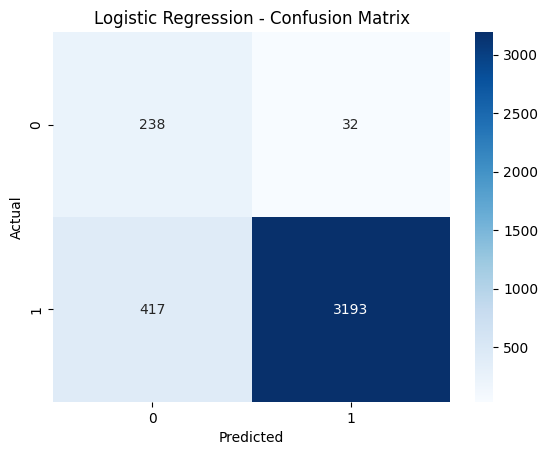

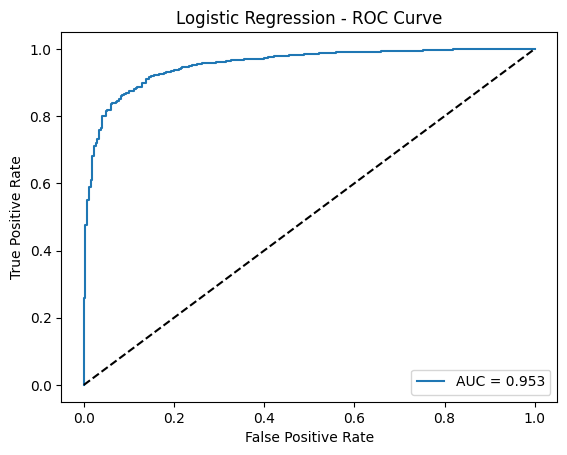


========== KNN ==========
Accuracy : 0.4229381443298969
Precision: 0.9906943450250537
Recall   : 0.38337950138504157
F1-score : 0.5528260435390453


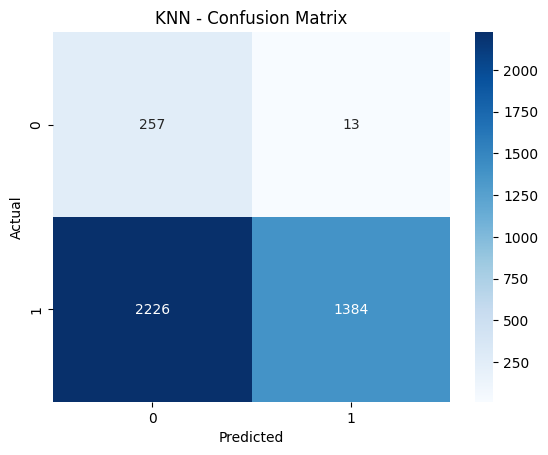

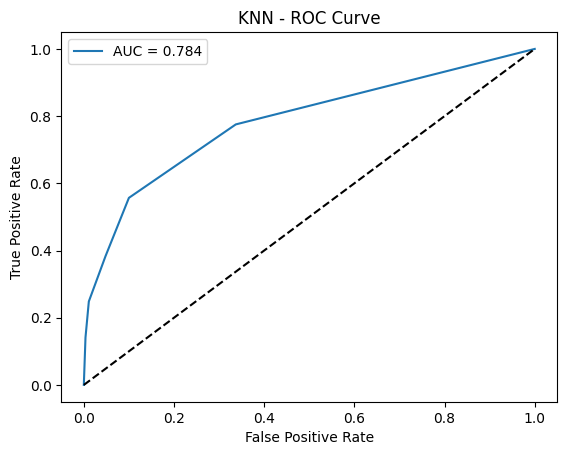


========== SVM ==========
Accuracy : 0.9337628865979382
Precision: 0.9715893108298171
Recall   : 0.9567867036011081
F1-score : 0.9641311933007676


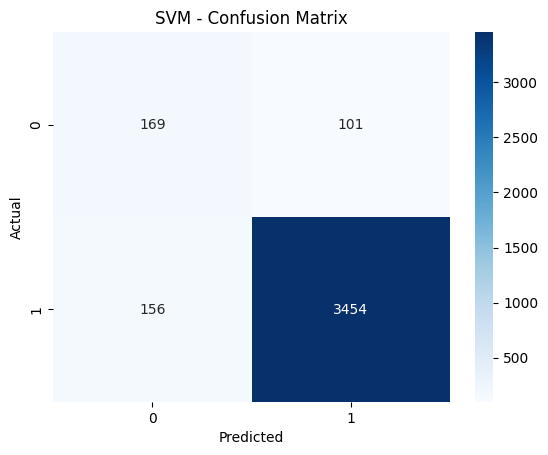

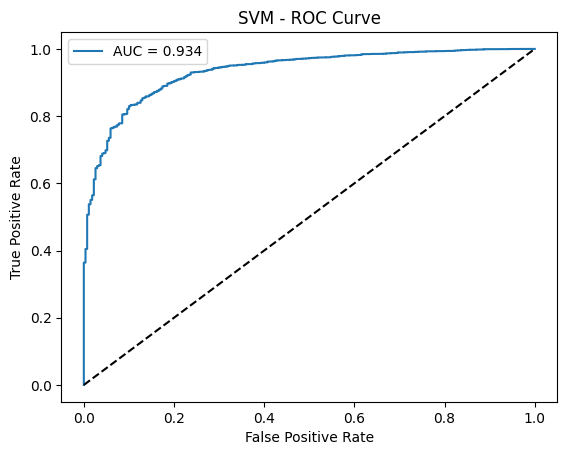


========== Naive Bayes ==========
Accuracy : 0.9115979381443299
Precision: 0.971973418087258
Recall   : 0.9318559556786704
F1-score : 0.9514920096167444


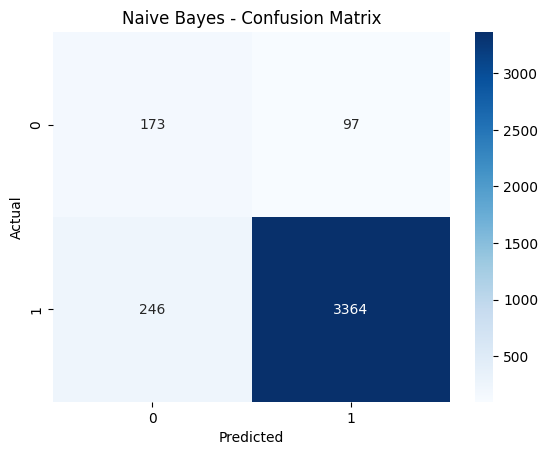

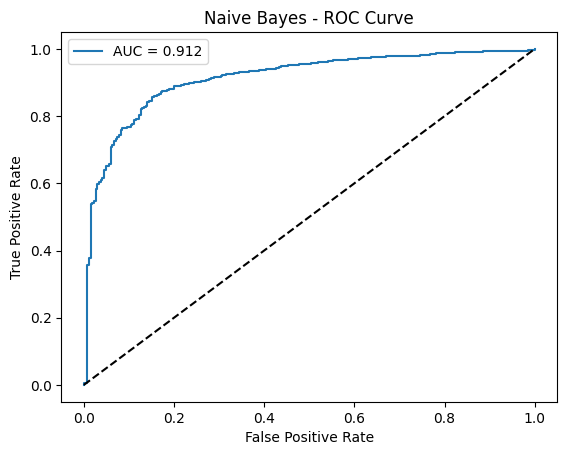


========== Decision Tree ==========
Accuracy : 0.8855670103092783
Precision: 0.9604421175101804
Recall   : 0.9146814404432133
F1-score : 0.9370034052213394


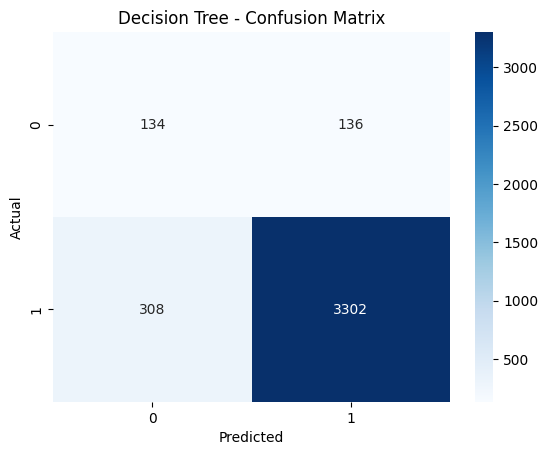

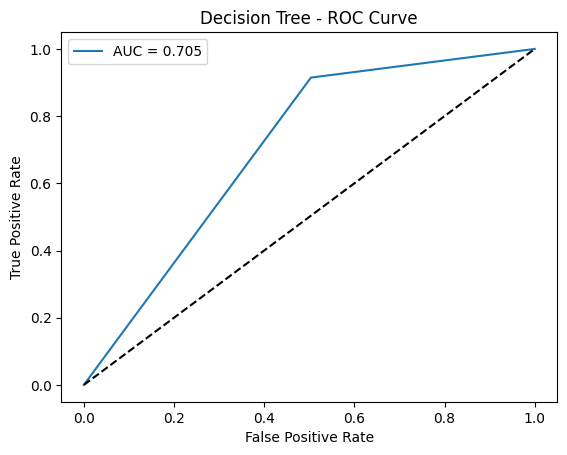


========== Random Forest ==========
Accuracy : 0.9355670103092784
Precision: 0.9545454545454546
Recall   : 0.9772853185595568
F1-score : 0.9657815494114427


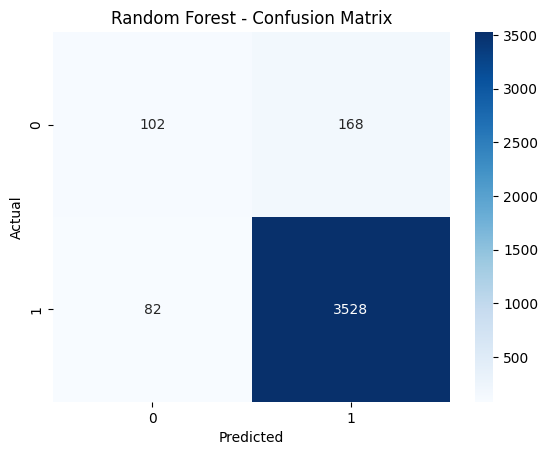

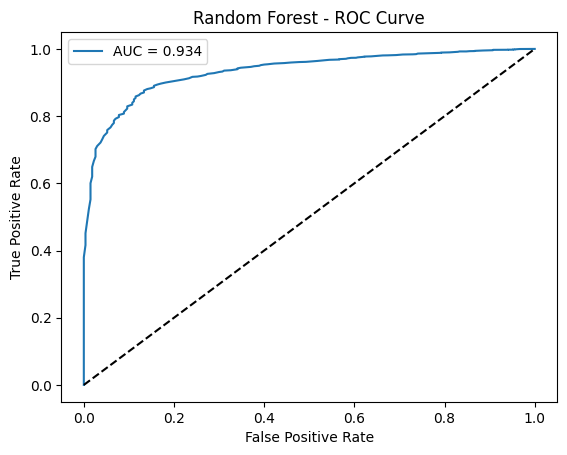


========== Gradient Boosting ==========
Accuracy : 0.9360824742268041
Precision: 0.9698155394074902
Recall   : 0.961218836565097
F1-score : 0.9654980523094046


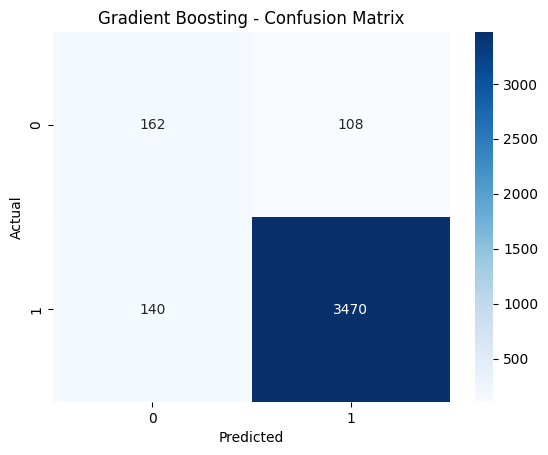

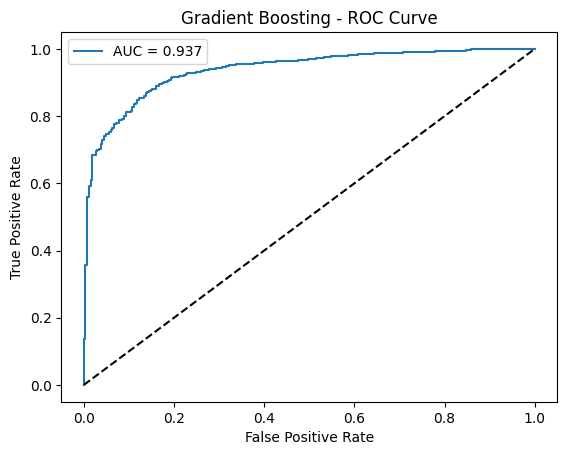

                       Feature  Importance
20               midterm_score    0.053273
19              quiz_avg_score    0.028943
18  assignment_submission_rate    0.023866
17     lecture_attendance_rate    0.023582
36           num_prerequisites    0.001727
4               family_support    0.001314
16     academic_warnings_count    0.000902
13      prior_semester_credits    0.000773
9            high_school_grade    0.000747
32          exam_anxiety_level    0.000490


In [37]:
# ==================================================
# 1. Imports
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTENC

from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score
)

# ==================================================
# 2. Load dataset
# ==================================================
df = pd.read_csv("Term_Project_Dataset_20K.csv")

# ==================================================
# 3. Drop unnecessary columns
# ==================================================
df = df.drop(columns=["final_score", "final_grade"])

# ==================================================
# 4. Remove rows with missing target & encode target
# ==================================================
df = df[df["pass_fail"].notna()]

X = df.drop(columns=["pass_fail"])

# Encode target: Fail = 0, Pass = 1
y = df["pass_fail"].map({
    "Fail": 0,
    "Pass": 1
})

# ==================================================
# 5. Encode categorical features
# ==================================================
X_encoded = X.copy()
label_encoders = {}

categorical_cols = X_encoded.select_dtypes(include=["object", "category"]).columns
numeric_cols = X_encoded.select_dtypes(include=["int64", "float64"]).columns

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# ==================================================
# 6. Train-test split
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# 7. Impute missing values
# ==================================================
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# ==================================================
# 8. Apply SMOTENC
# ==================================================
categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

smote = SMOTENC(categorical_features=categorical_features, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

# ==================================================
# 9. Scaling
# ==================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# ==================================================
# 10. Classification Models
# ==================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ==================================================
# 11. Classification Evaluation Function
# ==================================================
def evaluate_classification(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n========== {name} ==========")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC Curve")
        plt.legend()
        plt.show()

# ==================================================
# 12. Train & Evaluate Classification Models
# ==================================================
for name, model in models.items():
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        model.fit(X_train_smote, y_train_smote)
        evaluate_classification(model, X_test, y_test, name)
    else:
        model.fit(X_train_scaled, y_train_smote)
        evaluate_classification(model, X_test_scaled, y_test, name)

from sklearn.inspection import permutation_importance

r = permutation_importance(
    model,
    X_test_scaled if not isinstance(model, (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier)) else X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": r.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df.head(10))



# Semi-Supervised Approach

In [78]:
df

,age,parent_income,num_siblings,family_support,commute_time_min,previous_gpa,num_failed_courses,high_school_grade,math_background_score,language_background_score,...,num_prerequisites,gender_Male,gender_Unknown,part_time_job_Unknown,part_time_job_Yes,course_type_Mandatory,course_type_Unknown,final_score,final_grade,pass_fail
0,24.0,22678.0,0.0,1.0,95.0,2.220,3.0,99.7,34.0,91.0,...,3.0,False,False,False,False,False,False,NaN,C,Pass
1,21.0,17905.0,3.0,2.0,0.0,3.780,1.0,75.7,91.0,21.0,...,2.0,True,False,False,True,False,False,81.7,C,Pass
2,28.0,10469.2,0.0,0.0,67.0,2.104,4.0,93.4,32.0,30.0,...,3.0,True,False,False,False,False,False,77.3,B,Pass
3,25.0,29391.0,4.0,4.0,83.0,1.840,4.0,69.7,33.0,19.0,...,1.0,False,False,False,True,True,False,78.5,B,Pass
4,22.0,15522.0,0.0,4.0,58.0,3.380,0.0,62.2,89.0,48.0,...,1.0,True,False,False,True,True,False,60.3,D,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,27.0,12687.0,3.0,0.0,38.0,3.530,0.0,59.6,21.0,62.0,...,3.0,False,False,False,True,False,False,82.1,C,Pass
19996,25.0,8796.0,1.0,5.0,45.0,2.580,3.0,89.8,8.0,95.0,...,1.0,False,False,False,False,True,False,74.1,C,Pass
19997,24.0,21989.0,0.0,4.0,102.0,3.450,3.0,94.7,99.0,63.0,...,4.0,False,True,False,True,False,False,90.9,NaN,Pass
19998,27.0,28423.0,3.0,0.0,16.0,3.720,2.0,75.4,52.0,32.0,...,2.0,True,False,False,False,False,False,65.2,C,Pass


In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

# --- 1. SETUP AND STRATIFIED SPLIT ---
target_cols = ['pass_fail', 'final_grade', 'final_score']

df_unlabeled = df[df[target_cols].isnull().any(axis=1)].copy()
df_known = df[df[target_cols].notnull().all(axis=1)].copy()

# PRINT ORIGINAL SIZES
print(f"--- DATASET SIZES ---")
print(f"Total Rows in File:      {len(df)}")
print(f"Labeled (Known) Rows:    {len(df_known)}")
print(f"Unlabeled Rows:          {len(df_unlabeled)}")

df_train_orig, df_test = train_test_split(
    df_known, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_known['pass_fail']
)

print(f"Initial Training Set:    {len(df_train_orig)}")
print(f"Hold-out Test Set:       {len(df_test)}")

# --- 2. CLUSTERING FOR PSEUDO-LABELING ---
scaler_pre = StandardScaler()
X_train_pre = df_train_orig.drop(columns=target_cols)
X_unlabeled_pre = df_unlabeled.drop(columns=target_cols)

X_train_scaled_pre = scaler_pre.fit_transform(X_train_pre)
X_unlabeled_scaled_pre = scaler_pre.transform(X_unlabeled_pre)

k = 30 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_train_orig['cluster'] = kmeans.fit_predict(X_train_scaled_pre)
df_unlabeled['cluster'] = kmeans.predict(X_unlabeled_scaled_pre)

# --- 3. CALCULATE CLUSTER STATISTICS ---
cluster_stats = {}
for c_id in range(k):
    cluster_subset = df_train_orig[df_train_orig['cluster'] == c_id]
    if not cluster_subset.empty:
        mode_bin = cluster_subset['pass_fail'].mode()[0]
        cluster_stats[c_id] = {
            'binary': mode_bin,
            'multi': cluster_subset['final_grade'].mode()[0],
            'reg': cluster_subset['final_score'].mean(),
            'purity': (cluster_subset['pass_fail'] == mode_bin).mean()
        }

# --- 4. APPLY PSEUDO-LABELS ---
def apply_pseudo_labels(row):
    c_id = row['cluster']
    if c_id in cluster_stats and cluster_stats[c_id]['purity'] >= 0.9:
        return pd.Series([cluster_stats[c_id]['binary'], cluster_stats[c_id]['multi'], cluster_stats[c_id]['reg']])
    return pd.Series([np.nan, np.nan, np.nan])

df_unlabeled[target_cols] = df_unlabeled.apply(apply_pseudo_labels, axis=1)
df_pseudo_labeled = df_unlabeled.dropna(subset=target_cols).copy()

# FINAL CONCATENATION
df_final_train = pd.concat([df_train_orig, df_pseudo_labeled], axis=0).reset_index(drop=True)

# PRINT FINAL SIZES
print(f"Pseudo-labeled Rows:     {len(df_pseudo_labeled)}")
print(f"FINAL Training Set Size: {len(df_final_train)}")
print(f"----------------------\n")

# --- 5. FINAL FEATURE PREPARATION ---
features = [col for col in df_final_train.columns if col not in target_cols + ['cluster']]
X_train_final_scaled = StandardScaler().fit_transform(df_final_train[features])
X_test_final_scaled = StandardScaler().fit_transform(df_test[features])


--- DATASET SIZES ---
Total Rows in File:      20000
Labeled (Known) Rows:    18255
Unlabeled Rows:          1745
Initial Training Set:    14604
Hold-out Test Set:       3651
Pseudo-labeled Rows:     1427
FINAL Training Set Size: 16031
----------------------



## Final Score

### Lasso CV

In [102]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# --- 6-C. REGRESSION (LassoCV) ---

# 1. Prepare Target Variables
y_reg_train = df_final_train['final_score']
y_reg_test = df_test['final_score']

# 2. Initialize LassoCV
# cv=5: Performs 5-fold cross-validation to find the best alpha (penalty strength)
# selection='random': Often faster for large datasets
reg_model = LassoCV(cv=5, random_state=42, max_iter=10000)

# 3. Fit the model
reg_model.fit(X_train_final_scaled, y_reg_train)

# 4. Predict
pred_reg = reg_model.predict(X_test_final_scaled)

# --- 7-C. REGRESSION EVALUATION ---
mse = mean_squared_error(y_reg_test, pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, pred_reg)

print(f"--- REGRESSION RESULTS (LassoCV) ---")
print(f"Best Alpha: {reg_model.alpha_:.6f}")
print(f"R2 Score:   {r2:.4f}")
print(f"RMSE:       {rmse:.4f}")

# Optional: See how many features Lasso kept
n_features = X_train_final.shape[1]
n_kept = np.sum(reg_model.coef_ != 0)
print(f"Features kept by Lasso: {n_kept} out of {n_features}")

--- REGRESSION RESULTS (LassoCV) ---
Best Alpha: 0.042742
R2 Score:   0.7580
RMSE:       5.4728
Features kept by Lasso: 23 out of 41


### Linear SVR

In [103]:
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score

# --- 6-D. REGRESSION (Linear SVR) ---

# 1. Initialize LinearSVR
# C: Regularization parameter. Smaller values = more regularization.
# epsilon: The "tube" around the regression line where no penalty is given to errors.
# dual='auto': Helps the solver choose the most efficient algorithm based on sample size.
svr_model = LinearSVR(epsilon=0.1, C=1.0, random_state=42, max_iter=10000, dual='auto')

# 2. Fit the model
svr_model.fit(X_train_final_scaled, y_reg_train)

# 3. Predict
pred_svr = svr_model.predict(X_test_final_scaled)

# --- 7-D. SVR EVALUATION ---
svr_mse = mean_squared_error(y_reg_test, pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_reg_test, pred_svr)

print(f"--- REGRESSION RESULTS (Linear SVR) ---")
print(f"R2 Score:   {svr_r2:.4f}")
print(f"RMSE:       {svr_rmse:.4f}")

# Comparison Print
print(f"\nModel Comparison (R2):")
print(f"LassoCV:    {r2:.4f}")
print(f"LinearSVR:  {svr_r2:.4f}")

--- REGRESSION RESULTS (Linear SVR) ---
R2 Score:   0.7622
RMSE:       5.4246

Model Comparison (R2):
LassoCV:    0.7580
LinearSVR:  0.7622


### Non-Linear SVR

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform, loguniform

# --- 6-E. NON-LINEAR SVR WITH HYPERPARAMETER TUNING ---

# 1. Define the Parameter Distribution
# C: Regularization (how much we penalize errors)
# gamma: Kernel coefficient (defines how far the influence of a single point reaches)
# epsilon: The width of the "no-penalty" tube
param_dist = {
    'C': loguniform(1e-1, 1e3),
    'gamma': loguniform(1e-4, 1e-1),
    'epsilon': uniform(0.01, 1.0),
    'kernel': ['rbf'] 
}

# 2. Initialize the Base SVR Model
base_svr = SVR()

# 3. Setup Randomized Search
# n_iter=20: Number of different combinations to try
# cv=5: 5-fold cross-validation
svr_search = RandomizedSearchCV(
    estimator=base_svr,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1 # Uses all available CPU cores
)

# 4. Fit the Search
# We use y_reg_train (final_score) from the previous steps
svr_search.fit(X_train_final_scaled, y_reg_train)

# 5. Extract Best Model and Predict
best_svr = svr_search.best_estimator_
pred_nl_svr = best_svr.predict(X_test_final_scaled)

# --- 7-E. NON-LINEAR SVR EVALUATION ---
nl_svr_mse = mean_squared_error(y_reg_test, pred_nl_svr)
nl_svr_r2 = r2_score(y_reg_test, pred_nl_svr)

print(f"--- NON-LINEAR SVR RESULTS ---")
print(f"Best Params: {svr_search.best_params_}")
print(f"R2 Score:    {nl_svr_r2:.4f}")
print(f"RMSE:        {np.sqrt(nl_svr_mse):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
